In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "classification model",\n  "key": "KGAT_6b977a8599337f8d8ba3cd7f28823539"\n}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d sarangdilipjodh/indian-traffic-signs-prediction85-classes

Dataset URL: https://www.kaggle.com/datasets/sarangdilipjodh/indian-traffic-signs-prediction85-classes
License(s): CC0-1.0
 99% 1.12G/1.13G [00:05<00:00, 199MB/s]
100% 1.13G/1.13G [00:05<00:00, 211MB/s]


In [ ]:
!unzip indian-traffic-signs-prediction85-classes.zip

Streaming output truncated to the last 5000 lines.
  inflating: traffic_sign_classification_dataset/test/SLIPPERY_ROAD/61048.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63000.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63004.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63008.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63012.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63016.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63020.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63024.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63028.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63032.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED_LIMIT_15/63036.jpg  
  inflating: traffic_sign_classification_dataset/test/SPEED

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

dataset_path = "/content/traffic_sign_classification_dataset/train"

dataset = datasets.ImageFolder(root=dataset_path, transform=transform)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

num_classes = len(dataset.classes)
print("Number of classes:", num_classes)

Number of classes: 85


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(
    root="/content/traffic_sign_classification_dataset/train",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="/content/traffic_sign_classification_dataset/test",
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)

Dataset Loading

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

print("Loading datasets...")

# Load training dataset
train_dataset = datasets.ImageFolder(
    root="/content/traffic_sign_classification_dataset/train",
    transform=transform
)

# Load testing dataset
test_dataset = datasets.ImageFolder(
    root="/content/traffic_sign_classification_dataset/test",
    transform=transform
)

print("Datasets loaded successfully!")

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("DataLoaders created.")

# Extract class information
class_names = train_dataset.classes
num_classes = len(class_names)

print("\nDataset Information")
print("----------------------")
print("Number of Classes:", num_classes)
print("Class Names:", class_names)

print("\nTraining Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

print("\nBatch Size:", train_loader.batch_size)
print("Training Batches:", len(train_loader))
print("Testing Batches:", len(test_loader))

Loading datasets...
Datasets loaded successfully!
DataLoaders created.

Dataset Information
----------------------
Number of Classes: 85
Class Names: ['ALL_MOTOR_VEHICLE_PROHIBITED', 'AXLE_LOAD_LIMIT', 'BARRIER_AHEAD', 'BULLOCK_AND_HANDCART_PROHIBITED', 'BULLOCK_PROHIBITED', 'CATTLE', 'COMPULSARY_AHEAD', 'COMPULSARY_AHEAD_OR_TURN_LEFT', 'COMPULSARY_AHEAD_OR_TURN_RIGHT', 'COMPULSARY_CYCLE_TRACK', 'COMPULSARY_KEEP_LEFT', 'COMPULSARY_KEEP_RIGHT', 'COMPULSARY_MINIMUM_SPEED', 'COMPULSARY_SOUND_HORN', 'COMPULSARY_TURN_LEFT', 'COMPULSARY_TURN_LEFT_AHEAD', 'COMPULSARY_TURN_RIGHT', 'COMPULSARY_TURN_RIGHT_AHEAD', 'CROSS_ROAD', 'CYCLE_CROSSING', 'CYCLE_PROHIBITED', 'DANGEROUS_DIP', 'DIRECTION', 'FALLING_ROCKS', 'FERRY', 'GAP_IN_MEDIAN', 'GIVE_WAY', 'GUARDED_LEVEL_CROSSING', 'HANDCART_PROHIBITED', 'HEIGHT_LIMIT', 'HORN_PROHIBITED', 'HUMP_OR_ROUGH_ROAD', 'LEFT_HAIR_PIN_BEND', 'LEFT_HAND_CURVE', 'LEFT_REVERSE_BEND', 'LEFT_TURN_PROHIBITED', 'LENGTH_LIMIT', 'LOAD_LIMIT', 'LOOSE_GRAVEL', 'MEN_AT_WORK',

Load EfficientNet Model

In [ ]:
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(weights="IMAGENET1K_V1")

# Replace classifier layer
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 149MB/s]


Define Loss and Optimizer

In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Train the Model

In [ ]:
num_epochs = 50

train_losses = []
train_accuracies = []

for epoch in range(num_epochs):

    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss/len(train_loader)
    epoch_acc = 100*correct/total

    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.4f} Accuracy: {epoch_acc:.2f}%")

Epoch [1/50] Loss: 0.3013 Accuracy: 91.64%
Epoch [2/50] Loss: 0.1851 Accuracy: 94.39%
Epoch [3/50] Loss: 0.1028 Accuracy: 97.25%
Epoch [4/50] Loss: 0.1004 Accuracy: 97.18%
Epoch [5/50] Loss: 0.1021 Accuracy: 96.73%
Epoch [6/50] Loss: 0.0676 Accuracy: 97.72%
Epoch [7/50] Loss: 0.0716 Accuracy: 97.81%
Epoch [8/50] Loss: 0.0879 Accuracy: 97.48%
Epoch [9/50] Loss: 0.0430 Accuracy: 98.78%
Epoch [10/50] Loss: 0.0449 Accuracy: 98.58%
Epoch [11/50] Loss: 0.0459 Accuracy: 98.83%
Epoch [12/50] Loss: 0.0484 Accuracy: 98.42%
Epoch [13/50] Loss: 0.0488 Accuracy: 98.51%
Epoch [14/50] Loss: 0.0827 Accuracy: 97.48%
Epoch [15/50] Loss: 0.0883 Accuracy: 97.45%
Epoch [16/50] Loss: 0.0516 Accuracy: 98.17%
Epoch [17/50] Loss: 0.0682 Accuracy: 98.06%
Epoch [18/50] Loss: 0.0255 Accuracy: 99.21%
Epoch [19/50] Loss: 0.0231 Accuracy: 99.14%
Epoch [20/50] Loss: 0.0295 Accuracy: 99.08%
Epoch [21/50] Loss: 0.0349 Accuracy: 98.65%
Epoch [22/50] Loss: 0.0669 Accuracy: 97.84%
Epoch [23/50] Loss: 0.0401 Accuracy: 98.6

Print Evaluation Metrics

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate accuracy
accuracy = accuracy_score(all_labels, all_preds)

print("Test Accuracy:", accuracy * 100)

print("\nClassification Report:\n")

print(classification_report(all_labels, all_preds, target_names=class_names))

Test Accuracy: 95.1863354037267

Classification Report:

                                 precision    recall  f1-score   support

   ALL_MOTOR_VEHICLE_PROHIBITED       1.00      0.80      0.89         5
                AXLE_LOAD_LIMIT       1.00      1.00      1.00         5
                  BARRIER_AHEAD       1.00      1.00      1.00         2
BULLOCK_AND_HANDCART_PROHIBITED       0.67      1.00      0.80         2
             BULLOCK_PROHIBITED       1.00      0.60      0.75         5
                         CATTLE       0.69      1.00      0.81        11
               COMPULSARY_AHEAD       0.62      1.00      0.77        10
  COMPULSARY_AHEAD_OR_TURN_LEFT       1.00      1.00      1.00         4
 COMPULSARY_AHEAD_OR_TURN_RIGHT       1.00      0.33      0.50        12
         COMPULSARY_CYCLE_TRACK       1.00      1.00      1.00         4
           COMPULSARY_KEEP_LEFT       1.00      0.75      0.86        16
          COMPULSARY_KEEP_RIGHT       0.80      1.00      0.89    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Plot Training Graphs**

In [ ]:
import matplotlib.pyplot as plt

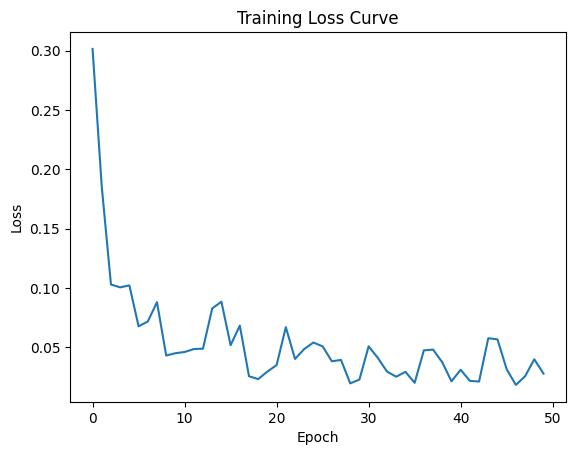

In [ ]:
plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

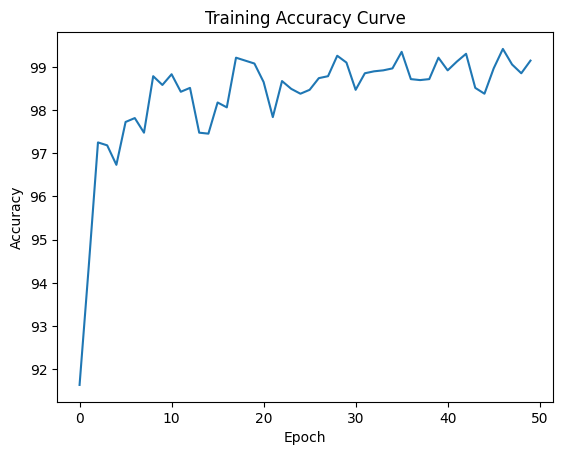

In [ ]:
plt.figure()
plt.plot(train_accuracies)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Curve")
plt.show()



Confusion Matrix



In [ ]:
from sklearn.metrics import confusion_matrix

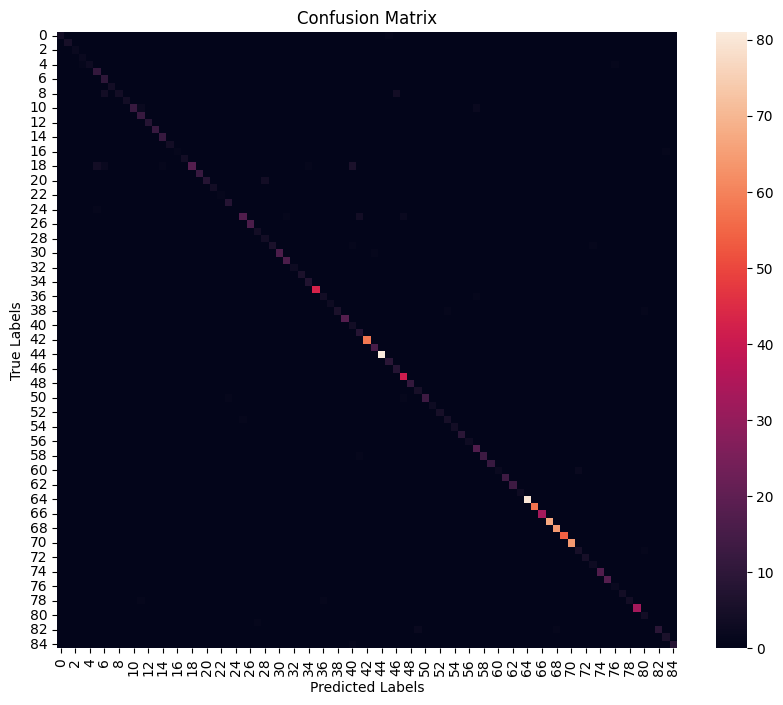

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))

sns.heatmap(cm, annot=False)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
torch.save(model.state_dict(), "traffic_sign_classifier_85.pth")

In [ ]:
from google.colab import files
files.download("traffic_sign_classifier_85.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>